# Azure Functions trace 2019

Two-week invocation counts (July 15–28, 2019) from [`data/azure2019`](data/azure2019). Each `invocations_per_function*.csv` file covers one day; columns `1`–`1440` are invocation counts per minute.

In [9]:
import re
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("ggplot")

DATA_DIR = Path("data/azure2019")
TRACE_START = pd.Timestamp("2019-07-15", tz="UTC")
TRACE_EPOCH = TRACE_START.timestamp()
ID_COLS = ["HashOwner", "HashApp", "HashFunction", "Trigger"]
MINUTE_COLS = [str(m) for m in range(1, 1441)]

In [10]:
def load_invocations_per_minute(data_dir: Path = DATA_DIR) -> pd.DataFrame:
    """Sum invocations across all functions into one row per minute."""
    frames = []
    for path in sorted(data_dir.glob("invocations_per_function*.csv")):
        day = int(re.search(r"\.d(\d+)\.csv$", path.name).group(1))
        minute_counts = pd.read_csv(path, usecols=lambda c: c.isdigit()).sum(axis=0)
        minute_counts.index = minute_counts.index.astype(int)
        timestamps = (
            TRACE_START
            + pd.Timedelta(days=day - 1)
            + pd.to_timedelta(minute_counts.index - 1, unit="m")
        )
        frames.append(
            pd.DataFrame({"timestamp": timestamps, "count": minute_counts.values})
        )
    return (
        pd.concat(frames, ignore_index=True)
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

# this cell takes about 20 seconds to run
df = load_invocations_per_minute()
df

,timestamp,count
0,2019-07-15 00:00:00+00:00,662592
1,2019-07-15 00:01:00+00:00,601633
2,2019-07-15 00:02:00+00:00,575989
3,2019-07-15 00:03:00+00:00,591299
4,2019-07-15 00:04:00+00:00,563383
...,...,...
20155,2019-07-28 23:55:00+00:00,611202
20156,2019-07-28 23:56:00+00:00,588891
20157,2019-07-28 23:57:00+00:00,578440
20158,2019-07-28 23:58:00+00:00,587982


<bound method NDFrame.head of timestamp
2019-07-15 00:00:00+00:00    32862030
2019-07-15 01:00:00+00:00    32746554
2019-07-15 02:00:00+00:00    34385569
2019-07-15 03:00:00+00:00    33641370
2019-07-15 04:00:00+00:00    34801510
                               ...   
2019-07-28 19:00:00+00:00    39336728
2019-07-28 20:00:00+00:00    38813980
2019-07-28 21:00:00+00:00    38925582
2019-07-28 22:00:00+00:00    38074656
2019-07-28 23:00:00+00:00    37146661
Freq: h, Name: count, Length: 336, dtype: int64>


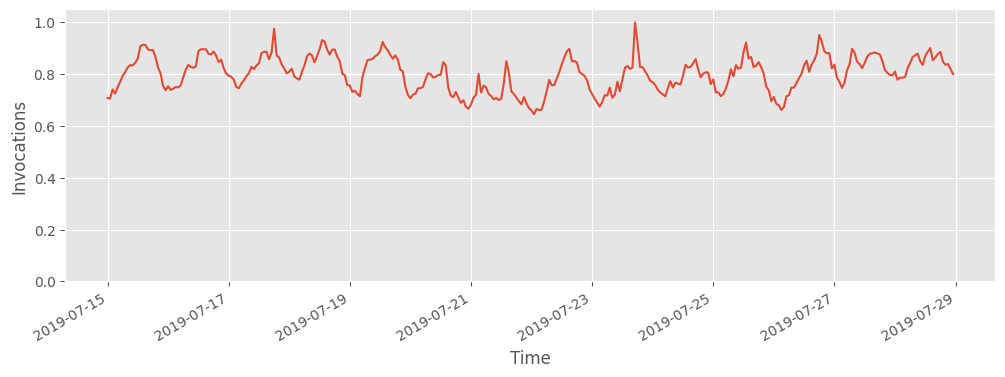

In [11]:
hourly = df.set_index("timestamp")["count"].resample("h").sum()
print(hourly.head)
hourly_norm = hourly / hourly.max()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(hourly_norm.index, hourly_norm.values)
ax.set_xlabel("Time")
ax.set_ylabel("Invocations")
ax.set_ylim(0, 1.05)
#ax.set_title("Azure Functions 2019 — hourly invocations (normalized)")
fig.autofmt_xdate()
plt.show()

In [12]:
def load_function_invocations(
    app: str,
    func: str,
    owner: str | None = None,
    data_dir: Path = DATA_DIR,
) -> pd.DataFrame:
    """Per-minute invocation counts for one function across all days."""
    frames = []
    for path in sorted(data_dir.glob("invocations_per_function*.csv")):
        day = int(re.search(r"\.d(\d+)\.csv$", path.name).group(1))
        day_df = pd.read_csv(path)
        mask = (day_df["HashApp"] == app) & (day_df["HashFunction"] == func)
        if owner is not None:
            mask &= day_df["HashOwner"] == owner
        rows = day_df.loc[mask, ID_COLS + [str(m) for m in range(1, 1441)]]
        if rows.empty:
            continue
        long = rows.melt(id_vars=ID_COLS, var_name="minute", value_name="count")
        long["minute"] = long["minute"].astype(int)
        long["timestamp"] = (
            TRACE_START
            + pd.Timedelta(days=day - 1)
            + pd.to_timedelta(long["minute"] - 1, unit="m")
        )
        frames.append(long.drop(columns="minute"))

    if not frames:
        raise ValueError(f"No rows found for app={app!r}, func={func!r}")

    return (
        pd.concat(frames, ignore_index=True)
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

## Inter-arrival times

The 2019 trace only has 1-minute invocation counts, so event times are reconstructed by spreading invocations uniformly within each minute. For each app/function, the mean inter-arrival time is the average gap between consecutive reconstructed events across the two-week trace.

In [29]:
def mean_inter_arrival_from_bins(epochs: np.ndarray, counts: np.ndarray) -> float:
    """Mean inter-arrival time (seconds) from per-minute invocation counts."""
    mask = counts > 0
    epochs = epochs[mask].astype(np.float64)
    counts = counts[mask].astype(np.int64)
    if counts.sum() < 2:
        return np.nan

    order = np.argsort(epochs)
    epochs = epochs[order]
    counts = counts[order]

    total_iat = 0.0
    n_gaps = int(counts.sum()) - 1
    prev_last = None
    for base, count in zip(epochs, counts):
        spacing = 60.0 / count
        first = base + 0.5 * spacing
        last = base + (count - 0.5) * spacing
        if count > 1:
            total_iat += spacing * (count - 1)
        if prev_last is not None:
            total_iat += first - prev_last
        prev_last = last
    return total_iat / n_gaps


def cv_inter_arrival_from_bins(epochs: np.ndarray, counts: np.ndarray) -> float:
    """Coefficient of variation of inter-arrival times from per-minute counts."""
    mask = counts > 0
    epochs = epochs[mask].astype(np.float64)
    counts = counts[mask].astype(np.int64)
    if counts.sum() < 3:
        return np.nan

    order = np.argsort(epochs)
    epochs = epochs[order]
    counts = counts[order]

    n = 0
    mean = 0.0
    m2 = 0.0
    prev_last = None

    def add_gap(gap: float) -> None:
        nonlocal n, mean, m2
        n += 1
        delta = gap - mean
        mean += delta / n
        m2 += delta * (gap - mean)

    for base, count in zip(epochs, counts):
        spacing = 60.0 / count
        first = base + 0.5 * spacing
        last = base + (count - 0.5) * spacing
        for _ in range(count - 1):
            add_gap(spacing)
        if prev_last is not None:
            add_gap(first - prev_last)
        prev_last = last

    if n < 2 or mean <= 0:
        return np.nan
    return (m2 / (n - 1)) ** 0.5 / mean


def load_inter_arrival_stats(
    data_dir: Path = DATA_DIR,
) -> tuple[pd.Series, pd.Series, pd.Series, dict[tuple[str, str], set[str]]]:
    """Return mean IAT, app mean IAT, app CV, and trigger sets per app."""
    func_bins: dict[tuple[str, str, str], tuple[list[float], list[int]]] = defaultdict(
        lambda: ([], [])
    )
    app_bins: dict[tuple[str, str], dict[float, int]] = defaultdict(lambda: defaultdict(int))
    app_triggers: dict[tuple[str, str], set[str]] = defaultdict(set)
    seen_functions: set[tuple[str, str, str]] = set()

    for path in sorted(data_dir.glob("invocations_per_function*.csv")):
        day = int(re.search(r"\.d(\d+)\.csv$", path.name).group(1))
        day_offset = (day - 1) * 86400
        day_df = pd.read_csv(path)
        counts = day_df[MINUTE_COLS].to_numpy(dtype=np.int32)
        rows, cols = np.nonzero(counts)

        owners = day_df["HashOwner"].to_numpy()[rows]
        apps = day_df["HashApp"].to_numpy()[rows]
        funcs = day_df["HashFunction"].to_numpy()[rows]
        triggers = day_df["Trigger"].to_numpy()[rows]
        epochs = TRACE_EPOCH + day_offset + cols.astype(np.float64) * 60.0
        values = counts[rows, cols]

        for owner, app, func, trigger, epoch, count in zip(
            owners, apps, funcs, triggers, epochs, values
        ):
            count = int(count)
            app_key = (owner, app)
            func_key = (owner, app, func)
            if func_key not in seen_functions:
                seen_functions.add(func_key)
                app_triggers[app_key].add(trigger)
            func_bins[func_key][0].append(epoch)
            func_bins[func_key][1].append(count)
            app_bins[app_key][epoch] += count

    mean_iat_by_function = pd.Series(
        {
            key: mean_inter_arrival_from_bins(np.array(epochs), np.array(counts))
            for key, (epochs, counts) in func_bins.items()
        },
        name="mean_iat_s",
    ).dropna()

    app_arrays = {
        key: (
            np.fromiter(epoch_counts.keys(), dtype=np.float64),
            np.fromiter(epoch_counts.values(), dtype=np.int64),
        )
        for key, epoch_counts in app_bins.items()
    }

    mean_iat_by_app = pd.Series(
        {
            key: mean_inter_arrival_from_bins(epochs, counts)
            for key, (epochs, counts) in app_arrays.items()
        },
        name="mean_iat_s",
    ).dropna()

    cv_by_app = pd.Series(
        {
            key: cv_inter_arrival_from_bins(epochs, counts)
            for key, (epochs, counts) in app_arrays.items()
        },
        name="cv",
    ).dropna()

    return mean_iat_by_function, mean_iat_by_app, cv_by_app, app_triggers


# this cell takes about 8-10 minutes to run
mean_iat_by_function, mean_iat_by_app, cv_by_app, app_triggers = load_inter_arrival_stats()
mean_iat_by_function.describe(), mean_iat_by_app.describe(), cv_by_app.describe()

(count    6.798900e+04
 mean     3.427103e+04
 std      8.798798e+04
 min      7.184058e-04
 25%      2.755443e+02
 50%      2.737590e+03
 75%      2.994821e+04
 max      1.138200e+06
 Name: mean_iat_s, dtype: float64,
 count     23697.000000
 mean      18638.646638
 std       64106.087690
 min           0.000672
 25%          65.266667
 50%         373.000000
 75%        6996.242236
 max      963120.000000
 Name: mean_iat_s, dtype: float64,
 count    23071.000000
 mean         7.420048
 std         39.369608
 min          0.000000
 25%          0.201564
 50%          1.466097
 75%          4.354494
 max       2783.394319
 Name: cv, dtype: float64)

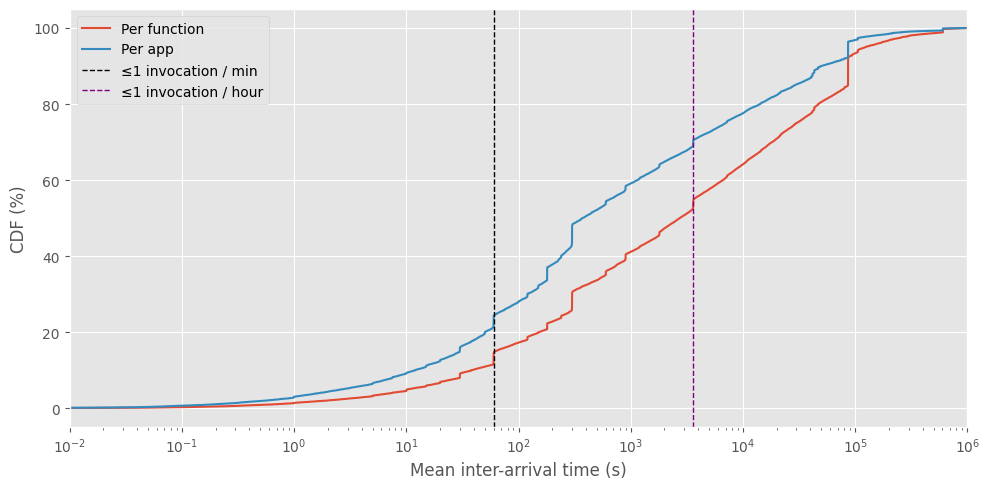

functions: 67,989
apps: 23,697

≤1 invocation / min (60 s)
  per function: 13.45%
  per app:      23.30%

≤1 invocation / hour (3600 s)
  per function: 54.48%
  per app:      70.33%



In [30]:
def get_cdf(values: pd.Series) -> tuple[np.ndarray, np.ndarray]:
    vals = np.sort(values.to_numpy())
    pct = 100.0 * np.arange(len(vals)) / len(vals)
    return vals, pct


def cdf_at(values: pd.Series, x: float) -> float:
    return 100.0 * (values <= x).mean()


fig, ax = plt.subplots(figsize=(10, 5))

func_vals, func_pct = get_cdf(mean_iat_by_function)
app_vals, app_pct = get_cdf(mean_iat_by_app)

ax.plot(func_vals, func_pct, label="Per function")
ax.plot(app_vals, app_pct, label="Per app")
ax.axvline(60, color="black", linestyle="--", linewidth=1, label="≤1 invocation / min")
ax.axvline(3600, color="purple", linestyle="--", linewidth=1, label="≤1 invocation / hour")
ax.set_xscale("log")
ax.set_xlim(0.01, 1000000)
ax.set_xlabel("Mean inter-arrival time (s)")
ax.set_ylabel("CDF (%)")
#ax.set_title("Azure Functions 2019 — average inter-arrival times")
ax.legend()
ax.grid(visible=True)
fig.tight_layout()
plt.show()

print(f"functions: {len(mean_iat_by_function):,}")
print(f"apps: {len(mean_iat_by_app):,}")
print()
for threshold, label in [(60, "≤1 invocation / min"), (3600, "≤1 invocation / hour")]:
    print(f"{label} ({threshold} s)")
    print(f"  per function: {cdf_at(mean_iat_by_function, threshold):.2f}%")
    print(f"  per app:      {cdf_at(mean_iat_by_app, threshold):.2f}%")
    print()

## Inter-arrival CV by app trigger type

Coefficient of variation (σ / μ) of reconstructed inter-arrival times per application, split by whether the app contains timer-triggered functions.

All apps: 23,071 apps
Only timer: 6,601 apps
At least one timer: 10,610 apps
No timer: 12,461 apps

All applications: 1,804 apps with CV = 0
Only timers: 1,499 apps with CV = 0
At least one timer: 1,502 apps with CV = 0
No timers: 302 apps with CV = 0


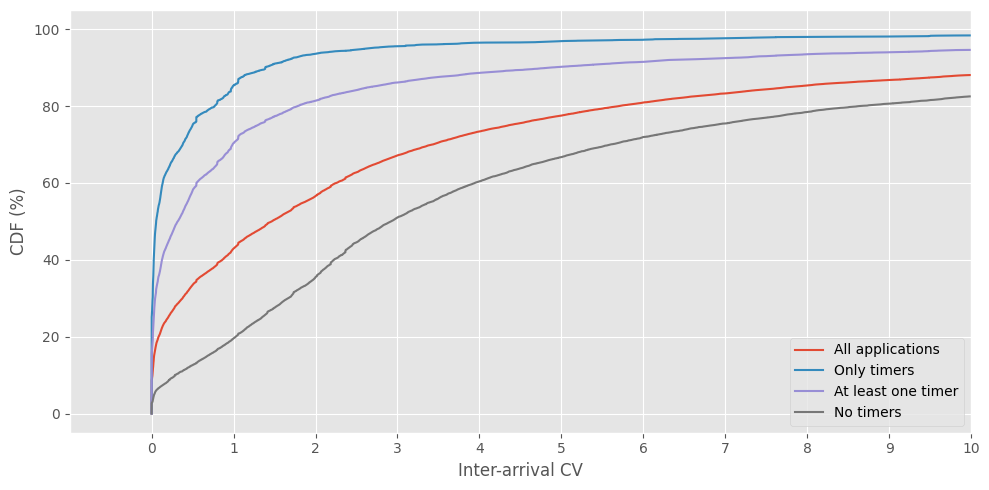

In [39]:
def filter_cv(label: str, predicate) -> pd.Series:
    series = cv_by_app[[k for k in cv_by_app.index if predicate(app_triggers[k])]]
    print(f"{label}: {len(series):,} apps")
    return series


cv_all = cv_by_app
print(f"All apps: {len(cv_all):,} apps")
cv_only_timer = filter_cv("Only timer", lambda triggers: triggers == {"timer"})
cv_any_timer = filter_cv("At least one timer", lambda triggers: "timer" in triggers)
cv_no_timer = filter_cv("No timer", lambda triggers: "timer" not in triggers)

fig, ax = plt.subplots(figsize=(10, 5))
plot_specs = [
    (cv_all, "All applications"),
    (cv_only_timer, "Only timers"),
    (cv_any_timer, "At least one timer"),
    (cv_no_timer, "No timers"),
]

print()
for series, label in plot_specs:
    n_zero = (series == 0).sum()
    print(f"{label}: {n_zero:,} apps with CV = 0")

for series, label in plot_specs:
    vals, pct = get_cdf(series)
    ax.plot(vals, pct, label=label)

#ax.set_xscale("log")
ax.set_xlim(-1, 10)
ax.set_xticks([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
ax.set_xlabel("Inter-arrival CV")
ax.set_ylabel("CDF (%)")
#ax.set_title("Azure Functions 2019 — inter-arrival CV per app")
ax.legend()
ax.grid(visible=True, which="major")
fig.tight_layout()
plt.show()